In [74]:
import pandas as pd;
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
#Učitavanje skupa sa pretvaranjem NA vrednosti u NaN.
csv = pd.read_csv('data/vendors.csv',na_values=['-', ' ', ''])
csv.info()

<class 'pandas.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   vendor_id                        22000 non-null  str    
 1   city                             22000 non-null  str    
 2   zone_type                        22000 non-null  str    
 3   vendor_age_years                 21242 non-null  float64
 4   years_in_business                20963 non-null  float64
 5   food_category                    22000 non-null  str    
 6   license_status                   21350 non-null  str    
 7   avg_daily_revenue_inr            20062 non-null  float64
 8   avg_daily_customers              20747 non-null  float64
 9   monthly_stall_rent_inr           20890 non-null  float64
 10  num_helpers                      22000 non-null  int64  
 11  hours_open_per_day               21558 non-null  float64
 12  competition_within_100m      

In [75]:
csv.head(10)

,vendor_id,city,zone_type,vendor_age_years,years_in_business,food_category,license_status,avg_daily_revenue_inr,avg_daily_customers,monthly_stall_rent_inr,num_helpers,hours_open_per_day,competition_within_100m,monthly_health_inspection_score,had_fine_last_year,avg_monthly_rainfall_mm,season_of_observation,has_online_presence,customer_complaint_rate,vendor_survived
0,VSF-00001,Delhi,Industrial,34.0,10.98,Chinese,Licensed,332.20,10.0,0.00,1,10.00,4.0,65.00,0.0,103.08,Winter,0.0,0.12,1
1,VSF-00002,Kochi,University Area,33.0,5.53,Chaat,Licensed,3138.90,180.0,2112.10,1,6.42,3.0,NaN,1.0,350.00,Monsoon,1.0,0.22,1
2,VSF-00003,Hyderabad,Industrial,48.0,2.70,Desserts & Sweets,Licensed,1626.36,67.0,5487.75,3,11.80,0.0,NaN,0.0,66.64,Post-Monsoon,0.0,0.09,0
3,VSF-00004,Bengaluru,Transit Hub,NaN,9.77,Beverages,Licensed,3592.98,171.0,1960.79,3,12.53,NaN,36.38,1.0,107.30,Post-Monsoon,1.0,0.10,1
4,VSF-00005,Delhi,Transit Hub,51.0,21.24,South Indian,Licensed,2418.07,105.0,2720.82,4,6.07,5.0,71.05,0.0,166.57,Monsoon,0.0,0.08,0
5,VSF-00006,Pune,Transit Hub,45.0,6.96,Chaat,Expired,1913.73,58.0,2305.32,0,10.91,14.0,58.75,1.0,166.91,Monsoon,NaN,0.11,0
6,VSF-00007,Mumbai,Transit Hub,74.0,16.69,Fast Food,Licensed,1475.99,68.0,5990.77,0,12.04,10.0,NaN,0.0,328.63,Monsoon,1.0,0.11,0
7,VSF-00008,Lucknow,University Area,43.0,15.15,South Indian,Licensed,1004.87,41.0,3641.78,2,NaN,1.0,95.00,0.0,111.85,Monsoon,0.0,0.22,0
8,VSF-00009,Bengaluru,Tourist Spot,31.0,0.90,Grilled & BBQ,Unlicensed,1026.87,44.0,2601.81,0,7.07,4.0,80.00,0.0,108.68,Post-Monsoon,0.0,0.21,1
9,VSF-00010,Mumbai,Tourist Spot,42.0,18.06,Seafood,Licensed,2149.48,83.0,7675.03,1,12.45,6.0,NaN,0.0,250.17,Winter,0.0,0.02,1


In [76]:
csv = csv.drop(columns=['vendor_id','city','zone_type','food_category','license_status','has_online_presence','avg_monthly_rainfall_mm','season_of_observation','had_fine_last_year'])
#Izbacujemo vendor id, city, zone type, rainfall  itd. što nije bilo na kolokvijumu, online presence takođe.
csv.info()
csv.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   vendor_age_years                 21242 non-null  float64
 1   years_in_business                20963 non-null  float64
 2   avg_daily_revenue_inr            20062 non-null  float64
 3   avg_daily_customers              20747 non-null  float64
 4   monthly_stall_rent_inr           20890 non-null  float64
 5   num_helpers                      22000 non-null  int64  
 6   hours_open_per_day               21558 non-null  float64
 7   competition_within_100m          21116 non-null  float64
 8   monthly_health_inspection_score  14241 non-null  float64
 9   customer_complaint_rate          19580 non-null  float64
 10  vendor_survived                  22000 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 1.8 MB


,vendor_age_years,years_in_business,avg_daily_revenue_inr,avg_daily_customers,monthly_stall_rent_inr,num_helpers,hours_open_per_day,competition_within_100m,monthly_health_inspection_score,customer_complaint_rate,vendor_survived
0,34.0,10.98,332.20,10.0,0.00,1,10.00,4.0,65.00,0.12,1
1,33.0,5.53,3138.90,180.0,2112.10,1,6.42,3.0,NaN,0.22,1
2,48.0,2.70,1626.36,67.0,5487.75,3,11.80,0.0,NaN,0.09,0
3,NaN,9.77,3592.98,171.0,1960.79,3,12.53,NaN,36.38,0.10,1
4,51.0,21.24,2418.07,105.0,2720.82,4,6.07,5.0,71.05,0.08,0
5,45.0,6.96,1913.73,58.0,2305.32,0,10.91,14.0,58.75,0.11,0
6,74.0,16.69,1475.99,68.0,5990.77,0,12.04,10.0,NaN,0.11,0
7,43.0,15.15,1004.87,41.0,3641.78,2,NaN,1.0,95.00,0.22,0
8,31.0,0.90,1026.87,44.0,2601.81,0,7.07,4.0,80.00,0.21,1
9,42.0,18.06,2149.48,83.0,7675.03,1,12.45,6.0,NaN,0.02,1


In [77]:
#Pišemo koliko nedostajućih kolona ima.
for c in csv.columns:
    print(f"{c} : Missing {csv[c].isna().sum()} / {csv[c].count()}")

vendor_age_years : Missing 758 / 21242
years_in_business : Missing 1037 / 20963
avg_daily_revenue_inr : Missing 1938 / 20062
avg_daily_customers : Missing 1253 / 20747
monthly_stall_rent_inr : Missing 1110 / 20890
num_helpers : Missing 0 / 22000
hours_open_per_day : Missing 442 / 21558
competition_within_100m : Missing 884 / 21116
monthly_health_inspection_score : Missing 7759 / 14241
customer_complaint_rate : Missing 2420 / 19580
vendor_survived : Missing 0 / 22000


In [92]:
#Proveravamo normalnost kolona, prema rezultatima trebalo bi da su sve kolone normalne raspodele pa ih možemo menjati medijanom.
from scipy.stats import shapiro
for c in csv.columns:
    print(shapiro(csv[c],nan_policy='omit').statistic) # - TRIK! nan_policy=omit dozvoljava da ne izbacujemo nan vrednosti iz CSVa.
for c in csv.columns:
    csv[c] = csv[c].fillna(csv[c].median()) #Menjamo sve kolone.

0.34299138372080096
0.7925670807945542
0.9443450479092279
0.9656449665416508
0.6285359263306622


C:\Users\PECA\PycharmProjects\KolokvijumStabloOdlucivanja\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 22000.
  res = hypotest_fun_out(*samples, **kwds)


In [93]:
#Proverimo da li sad ima nan vrednosti.
for c in csv.columns:
    print(f"{c} : Missing {csv[c].isna().sum()} / {csv[c].count()}")

avg_daily_revenue_inr : Missing 0 / 22000
avg_daily_customers : Missing 0 / 22000
monthly_health_inspection_score : Missing 0 / 22000
customer_complaint_rate : Missing 0 / 22000
vendor_survived : Missing 0 / 22000


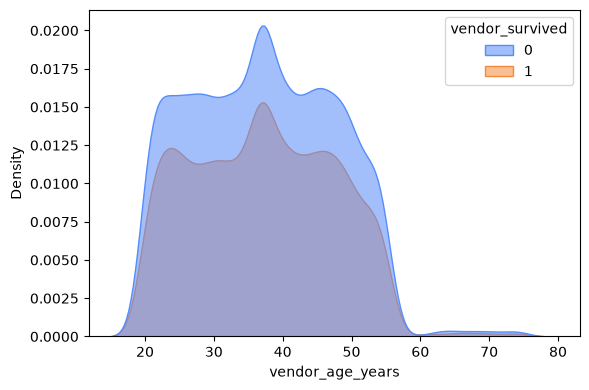

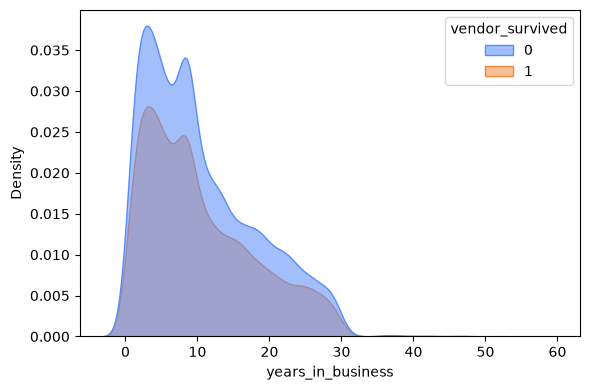

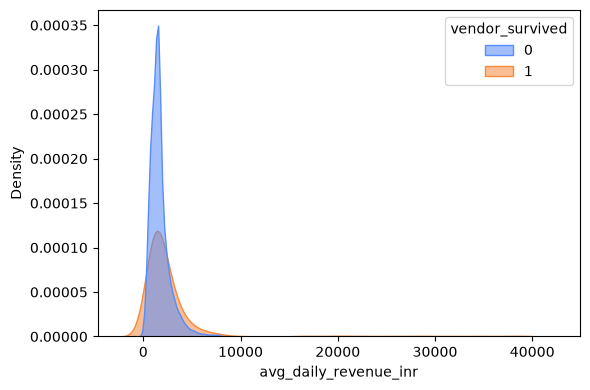

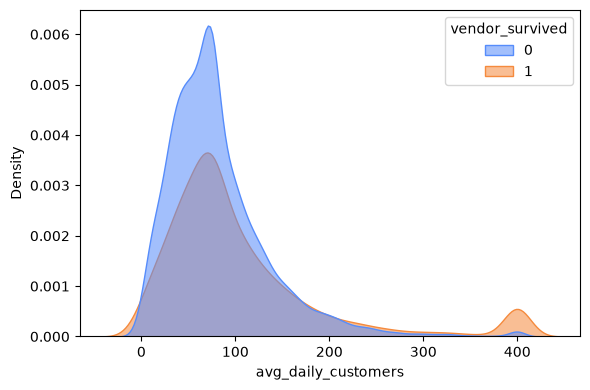

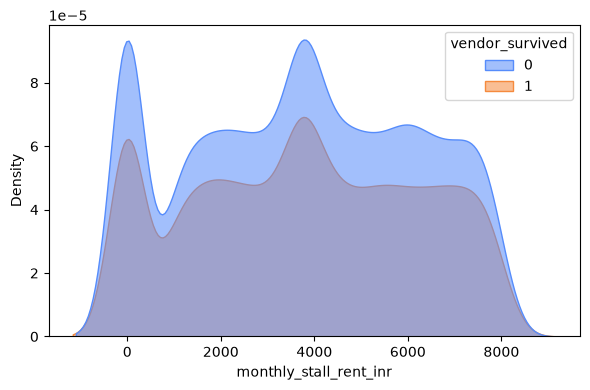

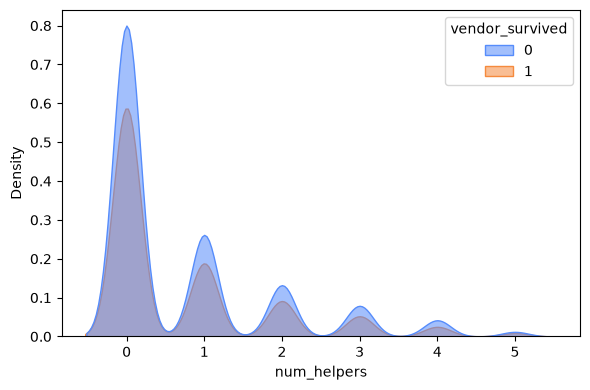

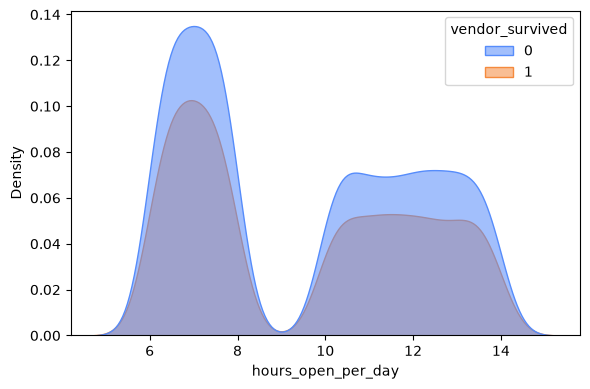

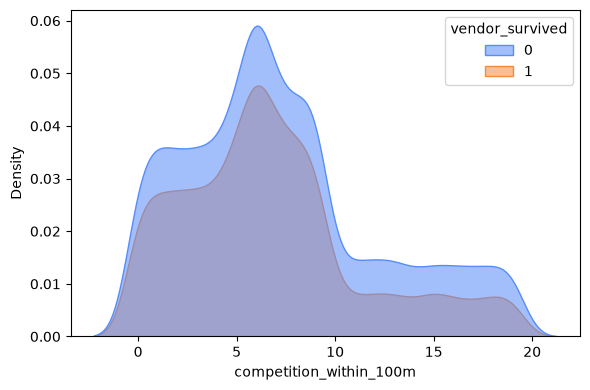

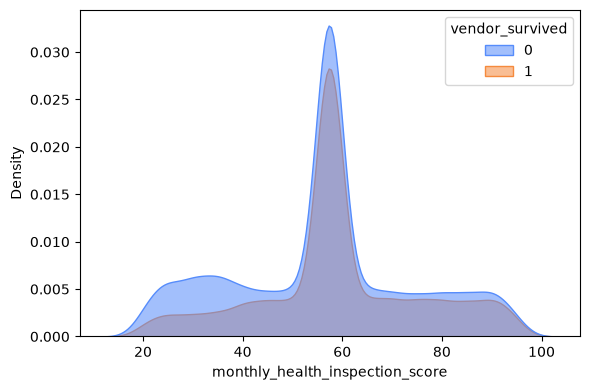

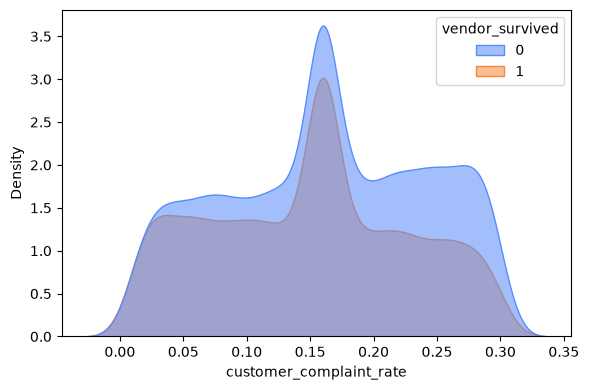

C:\Users\PECA\AppData\Local\Temp\ipykernel_15036\3550035804.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sb.kdeplot(csv,x=c,hue='vendor_survived',alpha=0.55,fill=True)


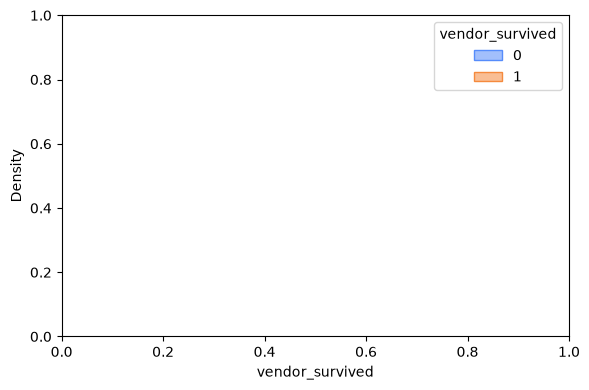

In [80]:
#KDE plotovi.
import matplotlib.pyplot as plt
import seaborn as sb
for c in csv.columns:
    plt.figure(figsize=(6,4))
    sb.kdeplot(csv,x=c,hue='vendor_survived',alpha=0.55,fill=True)
    plt.tight_layout()
    plt.show()

In [82]:
#Izbacujemo sledeće kolone jer im se raspodele preklapaju, te nisu statistički značajne.
csv = csv.drop(columns=['vendor_age_years','years_in_business','monthly_stall_rent_inr','num_helpers','hours_open_per_day','competition_within_100m'])
csv.info()
csv.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   avg_daily_revenue_inr            22000 non-null  float64
 1   avg_daily_customers              22000 non-null  float64
 2   monthly_health_inspection_score  22000 non-null  float64
 3   customer_complaint_rate          22000 non-null  float64
 4   vendor_survived                  22000 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 859.5 KB


,avg_daily_revenue_inr,avg_daily_customers,monthly_health_inspection_score,customer_complaint_rate,vendor_survived
0,332.20,10.0,65.00,0.12,1
1,3138.90,180.0,57.42,0.22,1
2,1626.36,67.0,57.42,0.09,0
3,3592.98,171.0,36.38,0.10,1
4,2418.07,105.0,71.05,0.08,0
5,1913.73,58.0,58.75,0.11,0
6,1475.99,68.0,57.42,0.11,0
7,1004.87,41.0,95.00,0.22,0
8,1026.87,44.0,80.00,0.21,1
9,2149.48,83.0,57.42,0.02,1


In [83]:
#Kreiramo izlaznu varijablu.
X = csv.drop(columns='vendor_survived')
y = csv['vendor_survived']


In [84]:
#Train test split.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [85]:
#Tražimo CCP alpha što je i najteži deo zadatka. Ovde i nema mnogo čega da se objašnjava.
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV,StratifiedKFold
cl = DecisionTreeClassifier()
kfold = StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
param_grid = {'ccp_alpha':[0.0,0.05,0.0025]}
gc = GridSearchCV(cl,param_grid=param_grid,cv=kfold)
gc.fit(X_train,y_train)
print("Best ccp alpha: ",gc.best_params_.get('ccp_alpha'))

Best ccp alpha:  0.0025


[Text(0.5555555555555556, 0.875, 'x[0] <= 1530.195\ngini = 0.489\nsamples = 17600\nvalue = [10122, 7478]\nclass = No'),
 Text(0.3333333333333333, 0.625, 'x[0] <= 1515.2\ngini = 0.451\nsamples = 9650\nvalue = [6329.0, 3321.0]\nclass = No'),
 Text(0.4444444444444444, 0.75, 'True  '),
 Text(0.2222222222222222, 0.375, 'x[2] <= 39.695\ngini = 0.484\nsamples = 8002\nvalue = [4709, 3293]\nclass = No'),
 Text(0.1111111111111111, 0.125, 'gini = 0.388\nsamples = 1289\nvalue = [949, 340]\nclass = No'),
 Text(0.3333333333333333, 0.125, 'gini = 0.493\nsamples = 6713\nvalue = [3760, 2953]\nclass = No'),
 Text(0.4444444444444444, 0.375, 'gini = 0.033\nsamples = 1648\nvalue = [1620, 28]\nclass = No'),
 Text(0.7777777777777778, 0.625, 'x[0] <= 5798.225\ngini = 0.499\nsamples = 7950\nvalue = [3793, 4157]\nclass = Yes'),
 Text(0.6666666666666667, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'x[2] <= 38.49\ngini = 0.5\nsamples = 7253\nvalue = [3674, 3579]\nclass = No'),
 Text(0.5555555555555556, 0.1

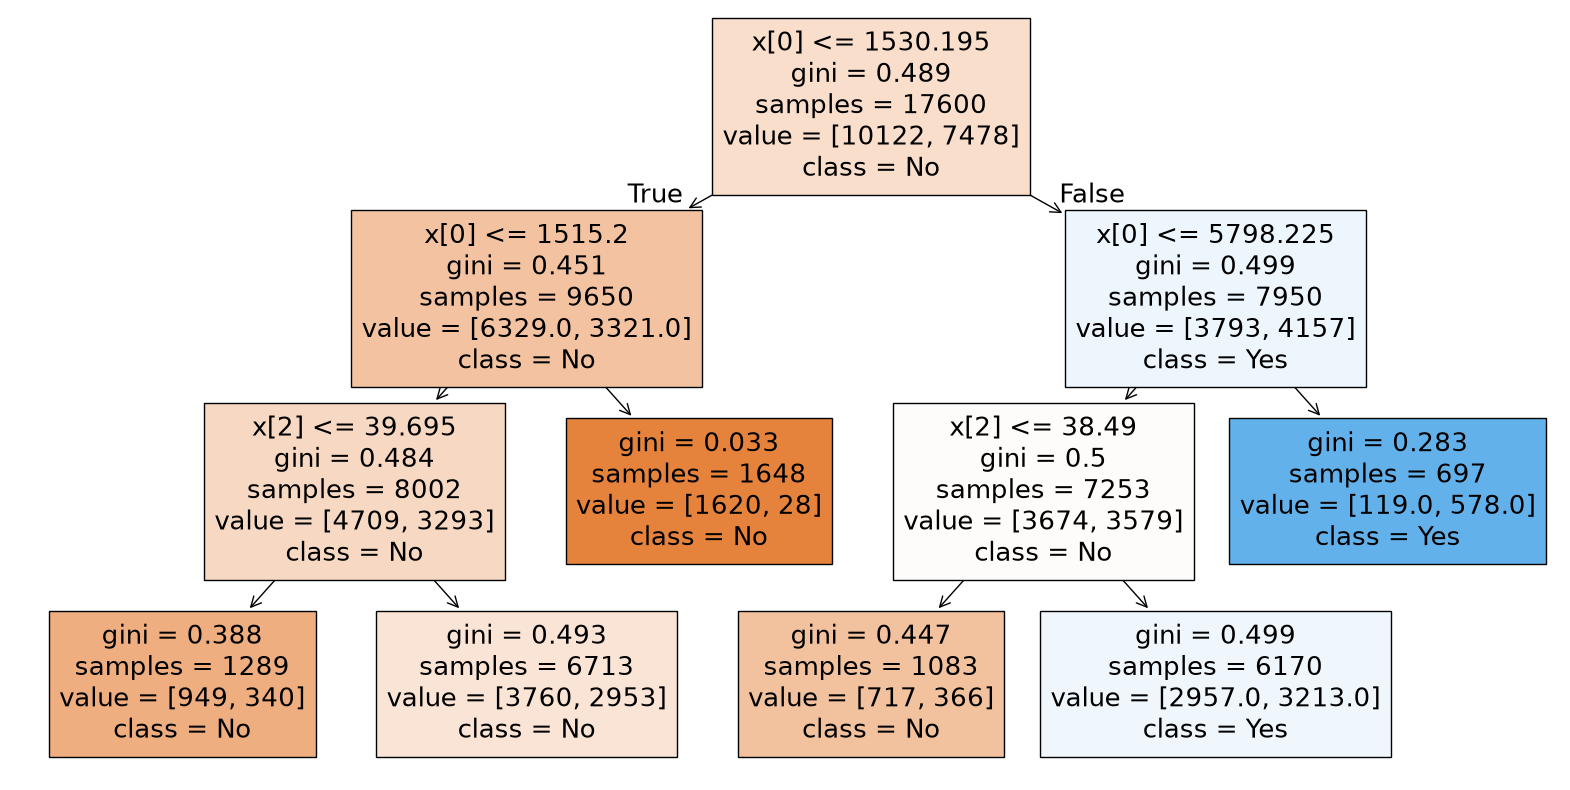

In [86]:
from sklearn.tree import plot_tree
#Kreiramo tree classifier na osnovu najboljeg parametra ccp_alpha i crtamo dijagram.
tree = DecisionTreeClassifier(ccp_alpha=gc.best_params_.get('ccp_alpha'),random_state=42)
tree.fit(X_train,y_train)
plt.figure(figsize=(20,10))
plot_tree(tree,class_names=['No','Yes'],filled=True)

In [87]:
y_pred = tree.predict(X_test)

<Figure size 600x400 with 0 Axes>

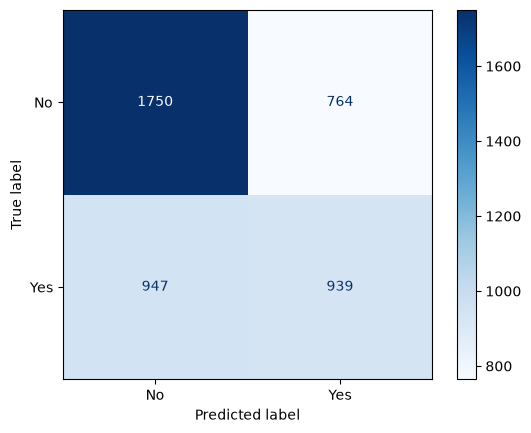

<Figure size 600x400 with 0 Axes>

In [88]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
c = ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap=plt.cm.Blues,display_labels=['No','Yes'])
plt.figure(figsize=(6,4))
#Iz matrice konfuzije saznajemo da smo tačno predvideli 1750 u klasi No, 939 u klasi Yes.

In [96]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print(f"Tačno predviđeno {round(accuracy*100,3)}% vrednosti.")
print(f"Realno procenjeno {round(precision*100,3)}% izlazne varijable.")
print(f"Realno predviđeno {round(recall*100,3)}% izlazne varijable.")
print(f"Procenat greške {round(f1*100,3)}%.")


Accuracy: 0.6111363636363636
Precision: 0.5513799177921316
Recall: 0.49787910922587486
F1: 0.523265533574812
Tačno predviđeno 61.114% vrednosti.
Realno procenjeno 55.138% izlazne varijable.
Realno predviđeno 49.788% izlazne varijable.
Procenat greške 52.327%.
